## Table of Contents

1.  [**Introduction**](#introduction)
2.  [**Data Loading**](#data-loading)
3.  [**Data Cleaning and Preprocessing**](#data-cleaning-and-preprocessing)
4.  [**Exploratory Data Analysis (EDA)**](#exploratory-data-analysis-eda)
5.  [**Key Insights from Fire Prevention Data Analysis**](#key-insights-from-fire-prevention-data-analysis)

# Fire Prevention Data Analysis: Identifying and Addressing Site Vulnerabilities

This notebook presents a comprehensive analysis of fire prevention data, aiming to identify vulnerable sites and prevalent problem types across various CMP (Central Maintenance Point) areas. The insights derived from this analysis will help in prioritizing interventions and allocating resources effectively to enhance site safety and prevent fire incidents.

<a id='data-loading'></a>
## 2. Data Loading

## Table of Contents

1.  [**Introduction**](#introduction)
2.  [**Data Loading**](#data-loading)
3.  [**Data Cleaning and Preprocessing**](#data-cleaning-and-preprocessing)
4.  [**Exploratory Data Analysis (EDA)**](#exploratory-data-analysis-eda)
5.  [**Key Findings and Recommendations**](#key-findings-and-recommendations)

<a id='introduction'></a>
## 1. Introduction

In [1]:
from google.colab import files
uploaded=files.upload()

Saving Fire_Prevention.xlsx to Fire_Prevention.xlsx


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report

The data is loaded from an Excel file named `Fire_Prevention.xlsx` into a pandas DataFrame. Initial inspection of the data structure and content is performed to understand its characteristics.

In [3]:
df=pd.read_excel('Fire_Prevention.xlsx')

<a id='data-cleaning-and-preprocessing'></a>
## 3. Data Cleaning and Preprocessing

In [4]:
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,994,1655,926,2206,692,846,731,738,725,Unnamed: 28
0,S.No,CMP,SAP ID,ENB/ESC,Site Type P1/RP1,GBM/Non GBM,Fire Free Site/Fire Vulnerable Sites,Tech Name,CI Name,CI PPRJ,...,Sealing of Roxtec/Exit Points & Entering of Po...,Installation of Rectifier Module on Sites with...,Correction of Bypass of Rectifier Module,Replacement of Faulty Class-C and Class-B SPD,Identification and replacement of Under Rated/...,Shifting of BM and SMPS from GBM to ODC on fea...,Deep Cleaning of Complete GBM Enclosure & remo...,Installation of Bird Mesh at GBM top Canopy,GBM Protection Ring installation at old GBM si...,Faults
1,1,Moradabad,I-UW-SMBL-ENB-9148,ENB,P1,NaN,Fire Free Site,ANIL SMBL,Yogesh Kumar,PPRJ00160724,...,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
2,2,Moradabad,I-UW-SMBL-ENB-9155,ENB,P1,NaN,Fire Free Site,avdesh,Yogesh Kumar,PPRJ00160724,...,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
3,3,Moradabad,I-UW-HSPR-ENB-9105,ENB,P1,NON GBM,Fire Free Site,MO SHADAM,Vipin Bhardwaj,PPRJ00106852,...,OK,OK,OK,OK,NaN,NaN,NaN,NaN,NaN,0
4,4,Moradabad,I-UW-RMPR-ENB-0001,ENB,P1,NON GBM,Fire Free Site,Dilshad Ansari,Mohit Sharma,PPRJ00092747,...,OK,OK,OK,OK,NaN,NaN,NaN,NaN,NaN,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7928 entries, 0 to 7927
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   7928 non-null   object
 1   Unnamed: 1   7928 non-null   object
 2   Unnamed: 2   7928 non-null   object
 3   Unnamed: 3   7928 non-null   object
 4   Unnamed: 4   7928 non-null   object
 5   Unnamed: 5   4606 non-null   object
 6   Unnamed: 6   7551 non-null   object
 7   Unnamed: 7   7915 non-null   object
 8   Unnamed: 8   7753 non-null   object
 9   Unnamed: 9   5653 non-null   object
 10  Unnamed: 10  3013 non-null   object
 11  Unnamed: 11  3013 non-null   object
 12  Unnamed: 12  273 non-null    object
 13  Unnamed: 13  273 non-null    object
 14  2330         7926 non-null   object
 15  1498         7926 non-null   object
 16  1532         7926 non-null   object
 17  1286         7926 non-null   object
 18  920          7926 non-null   object
 19  994          7926 non-null 

In [6]:
df.columns = df.iloc[0]
df = df[1:]
df = df.reset_index(drop=True)

In [7]:
df.head()

,S.No,CMP,SAP ID,ENB/ESC,Site Type P1/RP1,GBM/Non GBM,Fire Free Site/Fire Vulnerable Sites,Tech Name,CI Name,CI PPRJ,...,"Sealing of Roxtec/Exit Points & Entering of Power & ISP cables in ODC/GBM/DG in ""U"" Shape using Glands",Installation of Rectifier Module on Sites with <2 RM,Correction of Bypass of Rectifier Module,Replacement of Faulty Class-C and Class-B SPD,Identification and replacement of Under Rated/damage GBM Power Cable,Shifting of BM and SMPS from GBM to ODC on feasible sites,Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of unwanted Cable Bunch,Installation of Bird Mesh at GBM top Canopy,GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges,Faults
0,1,Moradabad,I-UW-SMBL-ENB-9148,ENB,P1,NaN,Fire Free Site,ANIL SMBL,Yogesh Kumar,PPRJ00160724,...,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
1,2,Moradabad,I-UW-SMBL-ENB-9155,ENB,P1,NaN,Fire Free Site,avdesh,Yogesh Kumar,PPRJ00160724,...,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
2,3,Moradabad,I-UW-HSPR-ENB-9105,ENB,P1,NON GBM,Fire Free Site,MO SHADAM,Vipin Bhardwaj,PPRJ00106852,...,OK,OK,OK,OK,NaN,NaN,NaN,NaN,NaN,0
3,4,Moradabad,I-UW-RMPR-ENB-0001,ENB,P1,NON GBM,Fire Free Site,Dilshad Ansari,Mohit Sharma,PPRJ00092747,...,OK,OK,OK,OK,NaN,NaN,NaN,NaN,NaN,0
4,5,Moradabad,I-UW-MDBD-ENB-0176,ENB,P1,NON GBM,Fire Free Site,Aas Mohammad,C.P SINGH,PPRJ00134454,...,OK,OK,OK,OK,NaN,NaN,NaN,NaN,NaN,0


The initial rows of the DataFrame contain headers that need to be correctly assigned as column names. This is followed by dropping irrelevant columns, handling missing values, and standardizing categorical data entries to ensure consistency.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7927 entries, 0 to 7926
Data columns (total 29 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   S.No                                                                                                                                                                    7927 non-null   object
 1   CMP                                                                                                                                                                     7927 non-null   object
 2   SAP ID                                                                                                  

In [9]:
df.isnull().sum()

,0
0,
S.No,0
CMP,0
SAP ID,0
ENB/ESC,0
Site Type P1/RP1,0
GBM/Non GBM,3322
Fire Free Site/Fire Vulnerable Sites,377
Tech Name,13
CI Name,175


In [10]:
df=df.drop(columns=['S.No'],axis=1)

In [11]:
df=df.drop(columns=['SAP ID'],axis=1)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7927 entries, 0 to 7926
Data columns (total 27 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7927 non-null   object
 1    ENB/ESC                                                                                                                                                                7927 non-null   object
 2   Site Type P1/RP1                                                                                        

In [13]:
df=df.drop(columns=['Tech Name'])

In [14]:
df=df.drop(columns=['CI Name','CI PPRJ','Visit Date','Visit Week','Closer Date','Closer Week'],axis=1)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7927 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7927 non-null   object
 1    ENB/ESC                                                                                                                                                                7927 non-null   object
 2   Site Type P1/RP1                                                                                        

In [16]:
df['GBM/Non GBM'].unique()

array([nan, 'NON GBM', 'GBM', 'Non GBM', 'GBT'], dtype=object)

In [17]:
df['GBM/Non GBM']=df['GBM/Non GBM'].fillna('GBM')

In [18]:
df['GBM/Non GBM'].unique()

array(['GBM', 'NON GBM', 'Non GBM', 'GBT'], dtype=object)

In [19]:
df['GBM/Non GBM']=df['GBM/Non GBM'].replace('Non GBM','NON GBM')

In [20]:
df['GBM/Non GBM'].unique()

array(['GBM', 'NON GBM', 'GBT'], dtype=object)

In [21]:
df['Fire Free Site/Fire Vulnerable Sites'].unique()

array(['Fire Free Site ', 'Fire Vulnerable Site', nan], dtype=object)

In [22]:
df['Fire Free Site/Fire Vulnerable Sites']=df['Fire Free Site/Fire Vulnerable Sites'].fillna('Fire Free Site ')

In [23]:
df['Fire Free Site/Fire Vulnerable Sites'].unique()

array(['Fire Free Site ', 'Fire Vulnerable Site'], dtype=object)

In [24]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['ok', 'OK', 'NOT OK', 'Ok', 'Not Ok', 'Not OK', 'Site Dismentle',
       nan, 'Site Switch-off'], dtype=object)

In [25]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].isnull().sum()

np.int64(2)

In [26]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].fillna('OK')

In [27]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].replace('Ok','OK')

In [28]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['ok', 'OK', 'NOT OK', 'Not Ok', 'Not OK', 'Site Dismentle',
       'Site Switch-off'], dtype=object)

In [29]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].replace('ok','OK')

In [30]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['OK', 'NOT OK', 'Not Ok', 'Not OK', 'Site Dismentle',
       'Site Switch-off'], dtype=object)

In [31]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].replace('Not ok','NOT OK')

In [32]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].replace('Not OK','NOT OK')

In [33]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['OK', 'NOT OK', 'Not Ok', 'Site Dismentle', 'Site Switch-off'],
      dtype=object)

In [34]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].replace('Not Ok','NOT OK')

In [35]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['OK', 'NOT OK', 'Site Dismentle', 'Site Switch-off'], dtype=object)

In [36]:
df[df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=='Site Dismentle']=df[df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=='Site Dismentle'].dropna()

In [37]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['OK', 'NOT OK', nan, 'Site Switch-off'], dtype=object)

In [38]:
df[df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=='Site Switch-off']=df[df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=='Site Switch-off'].dropna()

In [39]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [40]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].isnull().sum()

np.int64(2)

In [41]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].isnull().sum()

np.int64(4)

In [42]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].unique()

array(['ok', 'OK', 'NOT OK', ' OK', 'Ok', nan], dtype=object)

In [43]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box']=df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].replace('ok','OK')

In [44]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box']=df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].replace(' OK','OK')

In [45]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box']=df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].replace('Ok','OK')

In [46]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7927 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7925 non-null   object
 1    ENB/ESC                                                                                                                                                                7925 non-null   object
 2   Site Type P1/RP1                                                                                        

In [48]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', nan], dtype=object)

In [49]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ']=df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '].replace({'Ok':'OK'})

In [50]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '].unique()

array(['OK', 'ok', 'NOT OK', nan], dtype=object)

In [51]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ']=df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '].replace({'ok':'OK'})

In [52]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7927 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7925 non-null   object
 1    ENB/ESC                                                                                                                                                                7925 non-null   object
 2   Site Type P1/RP1                                                                                        

In [54]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].unique()

array(['OK', 'ok', 'NOT OK', 'EMG-21521', 'EMG-4539', 'EMG-4541',
       'EMG-4527', 'EMG-46205', 'Ok', 'EMG-114555', 'EMG-4544',
       'EMG-4540', 'EMG-45182', 'EMG-89414', 'EMG-4522', 'EMG-4575',
       'EMG-46209', 'EMG-46203', 'EMG-4622', 'EMG-112417', 'EMG-89415',
       'EMG-173246', nan, 'Not OK'], dtype=object)

In [55]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].value_counts()

,count
Illegal power tapping correction (DG AMF Panel/Mains EB meter Box),
OK,6223
NOT OK,1285
ok,201
Ok,195
EMG-21521,1
EMG-4541,1
EMG-4539,1
EMG-4527,1
EMG-46205,1


In [56]:
df['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR'].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', 'Not OK', nan], dtype=object)

In [57]:
df['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR']=df['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR'].replace({'ok':'OK','Ok':'OK','Not OK':'NOT OK'})

In [58]:
df['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR'].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [59]:
df['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands'].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', nan], dtype=object)

In [60]:
df['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands']=df['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands'].replace({'ok':'OK','Ok':'OK'})

In [61]:
df['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands'].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [62]:
df['Installation of Rectifier Module on Sites with <2 RM'].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', 'Not OK', nan], dtype=object)

In [63]:
df['Installation of Rectifier Module on Sites with <2 RM']=df['Installation of Rectifier Module on Sites with <2 RM'].replace({'ok':'OK','Ok':'OK','Not OK':'NOT OK'})

In [64]:
df['Installation of Rectifier Module on Sites with <2 RM'].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [65]:
df['Installation of Rectifier Module on Sites with <2 RM'].isnull().sum()

np.int64(4)

In [66]:
df['Correction of Bypass of Rectifier Module '].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', 'Not OK', 'Not Ok', 'NOT Ok', nan],
      dtype=object)

In [67]:
df['Correction of Bypass of Rectifier Module ']=df['Correction of Bypass of Rectifier Module '].replace({'ok':'OK','Ok':'OK','Not OK':'NOT OK','NOT Ok':'NOT OK','Not Ok':'NOT OK'})

In [68]:
df['Correction of Bypass of Rectifier Module '].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [69]:
df['Correction of Bypass of Rectifier Module '].isnull().sum()

np.int64(4)

In [70]:
df['Replacement of Faulty Class-C and Class-B SPD '].unique()

array(['OK', 'ok', 'NOT OK', 'Ok', 'Not Ok', 'Not OK', nan], dtype=object)

In [71]:
df['Replacement of Faulty Class-C and Class-B SPD ']=df['Replacement of Faulty Class-C and Class-B SPD '].replace({'ok':'OK','Ok':'OK','Not Ok':'NOT OK','Not OK':'NOT OK'})

In [72]:
df['Replacement of Faulty Class-C and Class-B SPD '].unique()

array(['OK', 'NOT OK', nan], dtype=object)

In [73]:
df['Replacement of Faulty Class-C and Class-B SPD '].isnull().sum()

np.int64(4)

In [74]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array(['OK', nan, 'ok', 'NOT OK'], dtype=object)

In [75]:
df['Identification and replacement of Under Rated/damage GBM Power Cable ']=df['Identification and replacement of Under Rated/damage GBM Power Cable '].replace({'ok':'OK'})

In [76]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array(['OK', nan, 'NOT OK'], dtype=object)

In [77]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].isnull().sum()

np.int64(5099)

In [78]:
df['Identification and replacement of Under Rated/damage GBM Power Cable ']=df['Identification and replacement of Under Rated/damage GBM Power Cable '].fillna('NO GBM')

In [79]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array(['OK', 'NO GBM', 'NOT OK'], dtype=object)

In [80]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].unique()

array(['OK', nan, 'NOT OK', 'Ok'], dtype=object)

In [81]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites']=df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].replace({'Ok':'OK'})

In [82]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].unique()

array(['OK', nan, 'NOT OK'], dtype=object)

In [83]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].isnull().sum()

np.int64(5099)

In [84]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites']=df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].fillna('NO GBM')

In [85]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].unique()

array(['OK', 'NO GBM', 'NOT OK'], dtype=object)

In [86]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].unique()

array(['OK', nan, 'NOT OK'], dtype=object)

In [87]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].isnull().sum()

np.int64(5076)

In [88]:
df.loc[df['Shifting of BM and SMPS from GBM to ODC on feasible sites'] == 'NO GBM', 'Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'] = 'NO GBM'

In [89]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].unique()

array(['OK', 'NO GBM', 'NOT OK'], dtype=object)

In [90]:
df

,CMP,ENB/ESC,Site Type P1/RP1,GBM/Non GBM,Fire Free Site/Fire Vulnerable Sites,"Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC & DG",Replacement of Under Rated/Faulty 4Core power cable in Meter Box,"Electrical Hygiene Correction ( Damage Insulation, Loose connection, Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment w/o using LUGS)",Illegal power tapping correction (DG AMF Panel/Mains EB meter Box),Removal of Faulty battery from Battery Management Power System & return to WH for RSNR,"Sealing of Roxtec/Exit Points & Entering of Power & ISP cables in ODC/GBM/DG in ""U"" Shape using Glands",Installation of Rectifier Module on Sites with <2 RM,Correction of Bypass of Rectifier Module,Replacement of Faulty Class-C and Class-B SPD,Identification and replacement of Under Rated/damage GBM Power Cable,Shifting of BM and SMPS from GBM to ODC on feasible sites,Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of unwanted Cable Bunch,Installation of Bird Mesh at GBM top Canopy,GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges,Faults
0,Moradabad,ENB,P1,GBM,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
1,Moradabad,ENB,P1,GBM,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,OK,0
2,Moradabad,ENB,P1,NON GBM,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
3,Moradabad,ENB,P1,NON GBM,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
4,Moradabad,ENB,P1,NON GBM,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7922,Muzaffarnagar,ENB,RP1,GBT,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
7923,Muzaffarnagar,ENB,P1,GBT,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
7924,Muzaffarnagar,ENB,RP1,GBT,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0
7925,Muzaffarnagar,ENB,P1,GBT,Fire Free Site,OK,OK,OK,OK,OK,OK,OK,OK,OK,NO GBM,NO GBM,NO GBM,NaN,NaN,0


In [91]:
df.loc[df['Shifting of BM and SMPS from GBM to ODC on feasible sites'] == 'NON GBM', 'Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'] = 'NON GBM'

In [92]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].unique()

array(['OK', 'NO GBM', 'NOT OK'], dtype=object)

In [93]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].value_counts()

,count
Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of unwanted Cable Bunch,
NO GBM,5099
OK,2097
NOT OK,731


In [94]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].value_counts()

,count
Identification and replacement of Under Rated/damage GBM Power Cable,
NO GBM,5099
OK,2136
NOT OK,692


In [95]:
df['Installation of Bird Mesh at GBM top Canopy'].unique()

array(['OK', nan, 'NOT OK'], dtype=object)

In [96]:
df['Installation of Bird Mesh at GBM top Canopy']=df['Installation of Bird Mesh at GBM top Canopy'].fillna('NO GBM')

In [97]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].unique()

array(['OK', nan, 'ok', 'NOT OK'], dtype=object)

In [98]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges']=df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].replace({'ok':'OK'})

In [99]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].unique()

array(['OK', nan, 'NOT OK'], dtype=object)

In [100]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges']=df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].fillna('NO GBM')

In [101]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].value_counts()

,count
GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges,
NO GBM,5099
OK,2103
NOT OK,725


In [102]:
df['Faults'].unique()

array([0, 3, 2, 1, 4, 5, 14, 6, 8, 9, 13, 7, nan], dtype=object)

In [103]:
df['Faults'].value_counts()

,count
Faults,
0,4250
1,1082
2,823
14,618
3,425
4,299
7,244
5,88
13,71


In [104]:
df=df.dropna()

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7923 non-null   object
 1    ENB/ESC                                                                                                                                                                7923 non-null   object
 2   Site Type P1/RP1                                                                                             

In [106]:
df.isnull().sum()

,0
0,
CMP,0
ENB/ESC,0
Site Type P1/RP1,0
GBM/Non GBM,0
Fire Free Site/Fire Vulnerable Sites,0
"Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC & DG",0
Replacement of Under Rated/Faulty 4Core power cable in Meter Box,0
"Electrical Hygiene Correction ( Damage Insulation, Loose connection, Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment w/o using LUGS)",0
Illegal power tapping correction (DG AMF Panel/Mains EB meter Box),0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7923 non-null   object
 1    ENB/ESC                                                                                                                                                                7923 non-null   object
 2   Site Type P1/RP1                                                                                             

In [108]:
df[' ENB/ESC'].unique()

array(['ENB', 'ESC'], dtype=object)

In [109]:
df=pd.get_dummies(df,columns=[' ENB/ESC'],drop_first=True)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 20 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                                                                                  --------------  ----- 
 0   CMP                                                                                                                                                                     7923 non-null   object
 1   Site Type P1/RP1                                                                                                                                                        7923 non-null   object
 2   GBM/Non GBM                                                                                                  

In [111]:
df['Site Type P1/RP1'].unique()

array(['P1', 'RP1', 'AG1', 'ESC / HP-ODSC', 'OLT/RP1', 'OLT/P1', 'ILA/P1',
       'AG1/P1', 'OLT/ESC', 'ESC', 'IP COLO', 'P1_GTL', 'RP1+LUT',
       'IP Colo', 'P1 '], dtype=object)

In [112]:
df=df.drop(columns=['Site Type P1/RP1'],axis=1)

In [113]:
df['Fire Free Site/Fire Vulnerable Sites'].unique()

array(['Fire Free Site ', 'Fire Vulnerable Site'], dtype=object)

In [114]:
oe=OrdinalEncoder(categories=[['Fire Free Site ', 'Fire Vulnerable Site']])
df['Fire Free Site/Fire Vulnerable Sites']=oe.fit_transform(df[['Fire Free Site/Fire Vulnerable Sites']])

In [115]:
df['Fire Free Site/Fire Vulnerable Sites'].unique()

array([0., 1.])

In [116]:
df['Fire Free Site/Fire Vulnerable Sites'].value_counts()

,count
Fire Free Site/Fire Vulnerable Sites,
0.0,4283
1.0,3640


In [117]:
oe=OrdinalEncoder(categories=[['OK', 'NOT OK']])

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [119]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']=oe.fit_transform(df[['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG']])

In [120]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box']=oe.fit_transform(df[['Replacement of Under Rated/Faulty 4Core power cable in Meter Box']])

In [121]:
df['Replacement of Under Rated/Faulty 4Core power cable in Meter Box'].unique()

array([0., 1.])

In [122]:
df['Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'].value_counts()

,count
"Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC & DG",
0.0,5593
1.0,2330


In [123]:
df['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ']=oe.fit_transform(df[['Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ']])

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [125]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].value_counts()

,count
Illegal power tapping correction (DG AMF Panel/Mains EB meter Box),
OK,6223
NOT OK,1285
ok,201
Ok,195
EMG-21521,1
EMG-4541,1
EMG-4539,1
EMG-4527,1
EMG-46205,1


In [126]:
df['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR']=oe.fit_transform(df[['Removal of Faulty battery from Battery Management Power System & return to WH for RSNR']])

In [127]:
df['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands']=oe.fit_transform(df[['Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands']])

In [128]:
df['Installation of Rectifier Module on Sites with <2 RM']=oe.fit_transform(df[['Installation of Rectifier Module on Sites with <2 RM']])

In [129]:
df['Correction of Bypass of Rectifier Module ']=oe.fit_transform(df[['Correction of Bypass of Rectifier Module ']])

In [130]:
df['Replacement of Faulty Class-C and Class-B SPD '].unique()

array(['OK', 'NOT OK'], dtype=object)

In [131]:
df['Replacement of Faulty Class-C and Class-B SPD ']=oe.fit_transform(df[['Replacement of Faulty Class-C and Class-B SPD ']])

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [133]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array(['OK', 'NO GBM', 'NOT OK'], dtype=object)

In [134]:
df['Identification and replacement of Under Rated/damage GBM Power Cable ']=df['Identification and replacement of Under Rated/damage GBM Power Cable '].replace({'OK':0,'NO GBM':0,'NOT OK':1})

/tmp/ipykernel_812/703754271.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Identification and replacement of Under Rated/damage GBM Power Cable ']=df['Identification and replacement of Under Rated/damage GBM Power Cable '].replace({'OK':0,'NO GBM':0,'NOT OK':1})


In [135]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array([0, 1])

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [137]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites']=df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].replace({'OK':0,'NO GBM':0,'NOT OK':1})

/tmp/ipykernel_812/1264668859.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Shifting of BM and SMPS from GBM to ODC on feasible sites']=df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].replace({'OK':0,'NO GBM':0,'NOT OK':1})


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [139]:
df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch']=df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].replace({'OK':0,'NO GBM':0,'NOT OK':1})


/tmp/ipykernel_812/1388457939.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch']=df['Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'].replace({'OK':0,'NO GBM':0,'NOT OK':1})


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [141]:
df['Installation of Bird Mesh at GBM top Canopy']=df['Installation of Bird Mesh at GBM top Canopy'].replace({'OK':0,'NO GBM':0,'NOT OK':1})

/tmp/ipykernel_812/3742831099.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Installation of Bird Mesh at GBM top Canopy']=df['Installation of Bird Mesh at GBM top Canopy'].replace({'OK':0,'NO GBM':0,'NOT OK':1})


In [142]:
df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges']=df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].replace({'OK':0,'NO GBM':0,'NOT OK':1})

/tmp/ipykernel_812/981778234.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges']=df['GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'].replace({'OK':0,'NO GBM':0,'NOT OK':1})


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [144]:
df['Faults'] = df['Faults'].astype(int)

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   object 
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [146]:
df['GBM/Non GBM'].unique()

array(['GBM', 'NON GBM', 'GBT'], dtype=object)

In [147]:
oe=OrdinalEncoder(categories=[['NON GBM','GBT','GBM']])

In [148]:
df['GBM/Non GBM']=oe.fit_transform(df[['GBM/Non GBM']])

In [149]:
df['GBM/Non GBM'].value_counts()

,count
GBM/Non GBM,
0.0,3885
2.0,3552
1.0,486


In [150]:
df['Shifting of BM and SMPS from GBM to ODC on feasible sites'].value_counts()

,count
Shifting of BM and SMPS from GBM to ODC on feasible sites,
0,7077
1,846


In [151]:
df['Identification and replacement of Under Rated/damage GBM Power Cable '].unique()

array([0, 1])

In [152]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].unique()

array(['OK', 'ok', 'NOT OK', 'EMG-21521', 'EMG-4539', 'EMG-4541',
       'EMG-4527', 'EMG-46205', 'Ok', 'EMG-114555', 'EMG-4544',
       'EMG-4540', 'EMG-45182', 'EMG-89414', 'EMG-4522', 'EMG-4575',
       'EMG-46209', 'EMG-46203', 'EMG-4622', 'EMG-112417', 'EMG-89415',
       'EMG-173246', 'Not OK'], dtype=object)

In [186]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'] = df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].replace({'ok':'OK','EMG-21521':'OK','EMG-4539':'OK','EMG-4541':'OK','EMG-4527':'OK','EMG-46205':'OK','Ok':'OK'})

In [154]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].unique()

array(['OK', 'NOT OK', 'EMG-114555', 'EMG-4544', 'EMG-4540', 'EMG-45182',
       'EMG-89414', 'EMG-4522', 'EMG-4575', 'EMG-46209', 'EMG-46203',
       'EMG-4622', 'EMG-112417', 'EMG-89415', 'EMG-173246', 'Not OK'],
      dtype=object)

In [155]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)']

,Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)
0,OK
1,OK
2,OK
3,OK
4,OK
...,...
7922,OK
7923,OK
7924,OK
7925,OK


In [156]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)']=df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].replace({'EMG-114555':'OK', 'EMG-4544' : 'OK', 'EMG-4540': 'OK', 'EMG-45182' : 'OK','EMG-89414' : 'OK', 'EMG-4522' : 'OK', 'EMG-4575' : 'OK', 'EMG-46209' : 'OK', 'EMG-46203' : 'OK','EMG-4622' : 'OK', 'EMG-112417' : 'OK', 'EMG-89415' : 'OK', 'EMG-173246' : 'OK', 'Not OK' : 'NOT OK'})

In [157]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'].unique()

array(['OK', 'NOT OK'], dtype=object)

In [158]:
oe=OrdinalEncoder(categories=[['OK','NOT OK']])

In [159]:
df['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)']=oe.fit_transform(df[['Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)']])

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   float64
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

In [161]:
df['CMP'].unique()

array(['Moradabad', 'ETAWAH', 'Bijnor', 'BIJNOR', 'AGRA', 'Meerut',
       'Hapur', 'Muzaffarnagar', 'Bareilly', 'Aligarh', 'Agra'],
      dtype=object)

In [162]:
df['CMP']=df['CMP'].replace({'Agra':'AGRA','Bijnor':'BIJNOR'})

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7923 entries, 0 to 7926
Data columns (total 19 columns):
 #   Column                                                                                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                                                                                  --------------  -----  
 0   CMP                                                                                                                                                                     7923 non-null   object 
 1   GBM/Non GBM                                                                                                                                                             7923 non-null   float64
 2   Fire Free Site/Fire Vulnerable Sites                                                                     

no of sites per area in the data


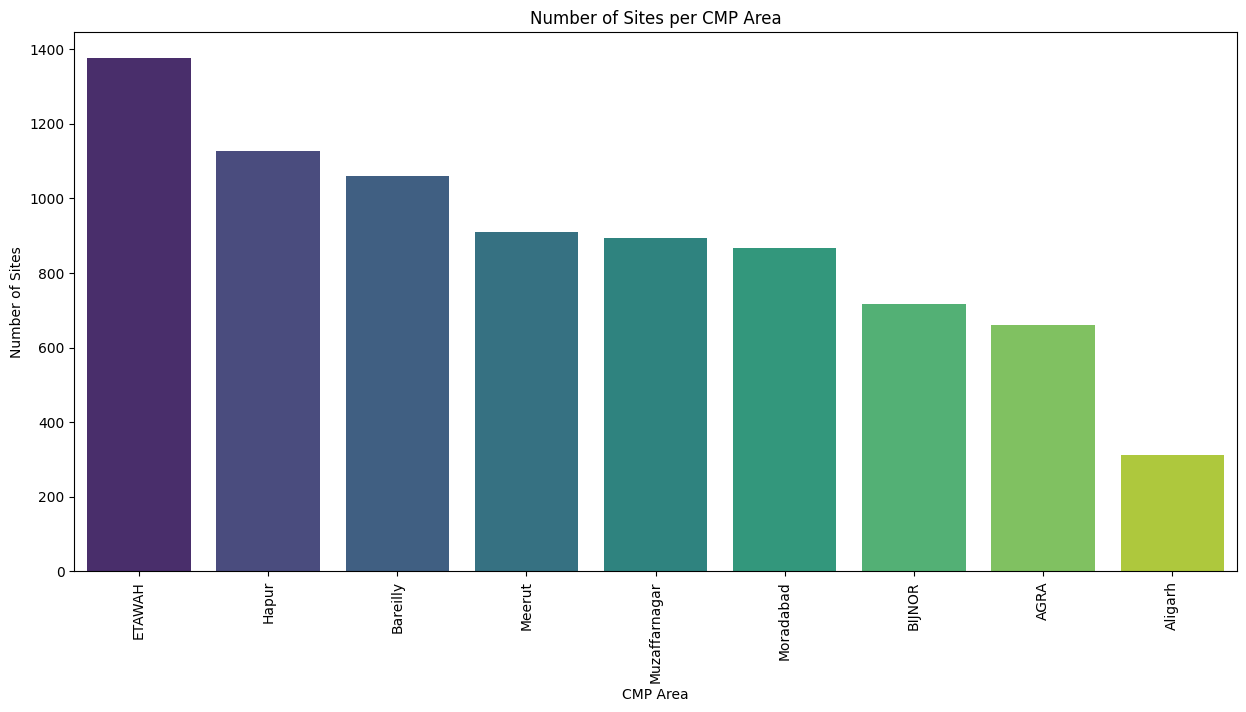

In [164]:
plt.figure(figsize=(15, 7))
sns.barplot(x=df['CMP'].value_counts().index, y=df['CMP'].value_counts().values, hue=df['CMP'].value_counts().index, palette='viridis', legend=False)
plt.title('Number of Sites per CMP Area')
plt.xlabel('CMP Area')
plt.ylabel('Number of Sites')
plt.xticks(rotation=90)
plt.show()

no of sites need actions (whose fault is more then 0 ) that need action and improvement

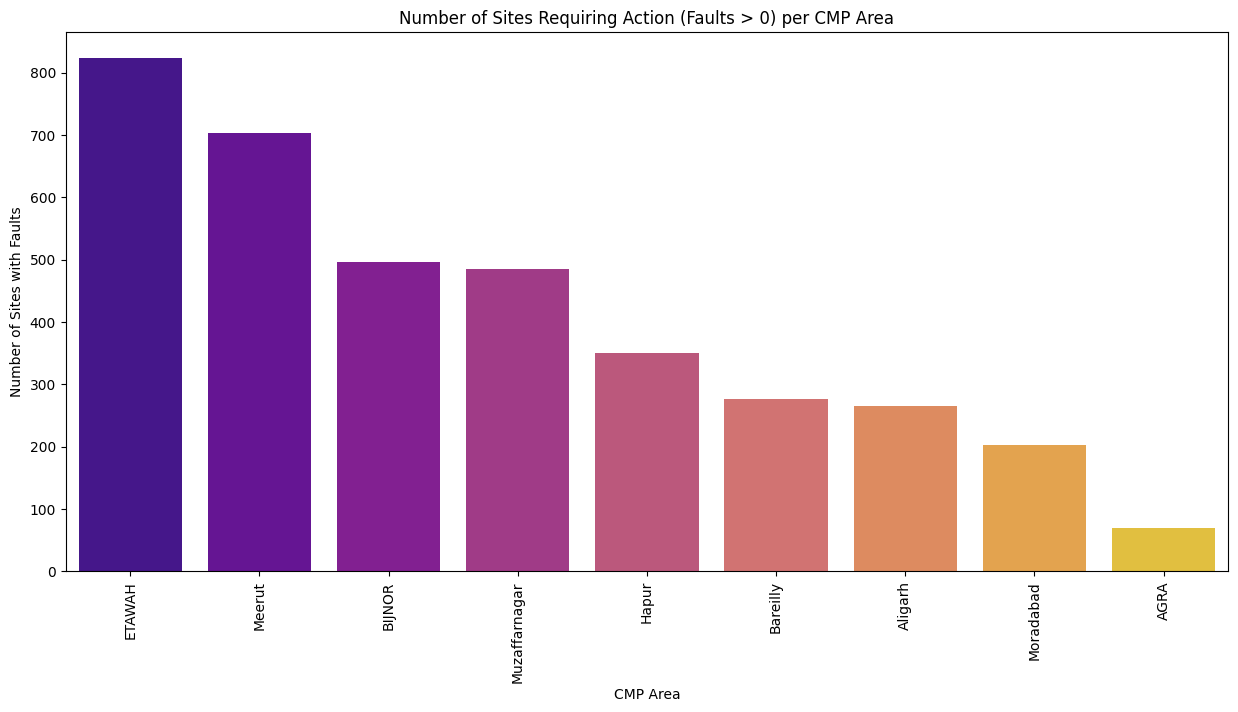

In [165]:
faulty_sites_per_cmp = df[df['Faults'] > 0].groupby('CMP').size().sort_values(ascending=False)

plt.figure(figsize=(15, 7))
sns.barplot(x=faulty_sites_per_cmp.index, y=faulty_sites_per_cmp.values, hue=faulty_sites_per_cmp.index, palette='plasma', legend=False)
plt.title('Number of Sites Requiring Action (Faults > 0) per CMP Area')
plt.xlabel('CMP Area')
plt.ylabel('Number of Sites with Faults')
plt.xticks(rotation=90)
plt.show()

In [166]:
total_sites = len(df)  #getting total no of sites
sites_with_faults = df[df['Faults'] > 0].shape[0]  #getting sites that has faults(need improvement )
percentage_sites_needing_action = (sites_with_faults / total_sites) * 100  #percentage of sites that has faults

print(f"Total number of sites: {total_sites}")
print(f"Number of sites needing action (Faults > 0): {sites_with_faults}")
print(f"Percentage of sites needing action: {percentage_sites_needing_action:.2f}%")

Total number of sites: 7923
Number of sites needing action (Faults > 0): 3675
Percentage of sites needing action: 46.38%


no of sites that are fine and not fine according to the data

In [167]:
cmp_action_summary = df.groupby('CMP')['Faults'].agg(
    total_sites='count',
    faulty_sites=lambda x: (x > 0).sum(),
    fine_sites=lambda x: (x == 0).sum()
).reset_index()

cmp_action_summary['Faulty_Percentage'] = (cmp_action_summary['faulty_sites'] / cmp_action_summary['total_sites']) * 100
cmp_action_summary['Fine_Percentage'] = (cmp_action_summary['fine_sites'] / cmp_action_summary['total_sites']) * 100

display(cmp_action_summary)

,CMP,total_sites,faulty_sites,fine_sites,Faulty_Percentage,Fine_Percentage
0,AGRA,660,70,590,10.606061,89.393939
1,Aligarh,311,266,45,85.530547,14.469453
2,BIJNOR,718,496,222,69.080780,30.919220
3,Bareilly,1059,277,782,26.156752,73.843248
4,ETAWAH,1377,824,553,59.840232,40.159768
5,Hapur,1127,351,776,31.144632,68.855368
6,Meerut,909,703,206,77.337734,22.662266
7,Moradabad,868,203,665,23.387097,76.612903
8,Muzaffarnagar,894,485,409,54.250559,45.749441


no of sites needed action and also no of sites that are fine according to different areas

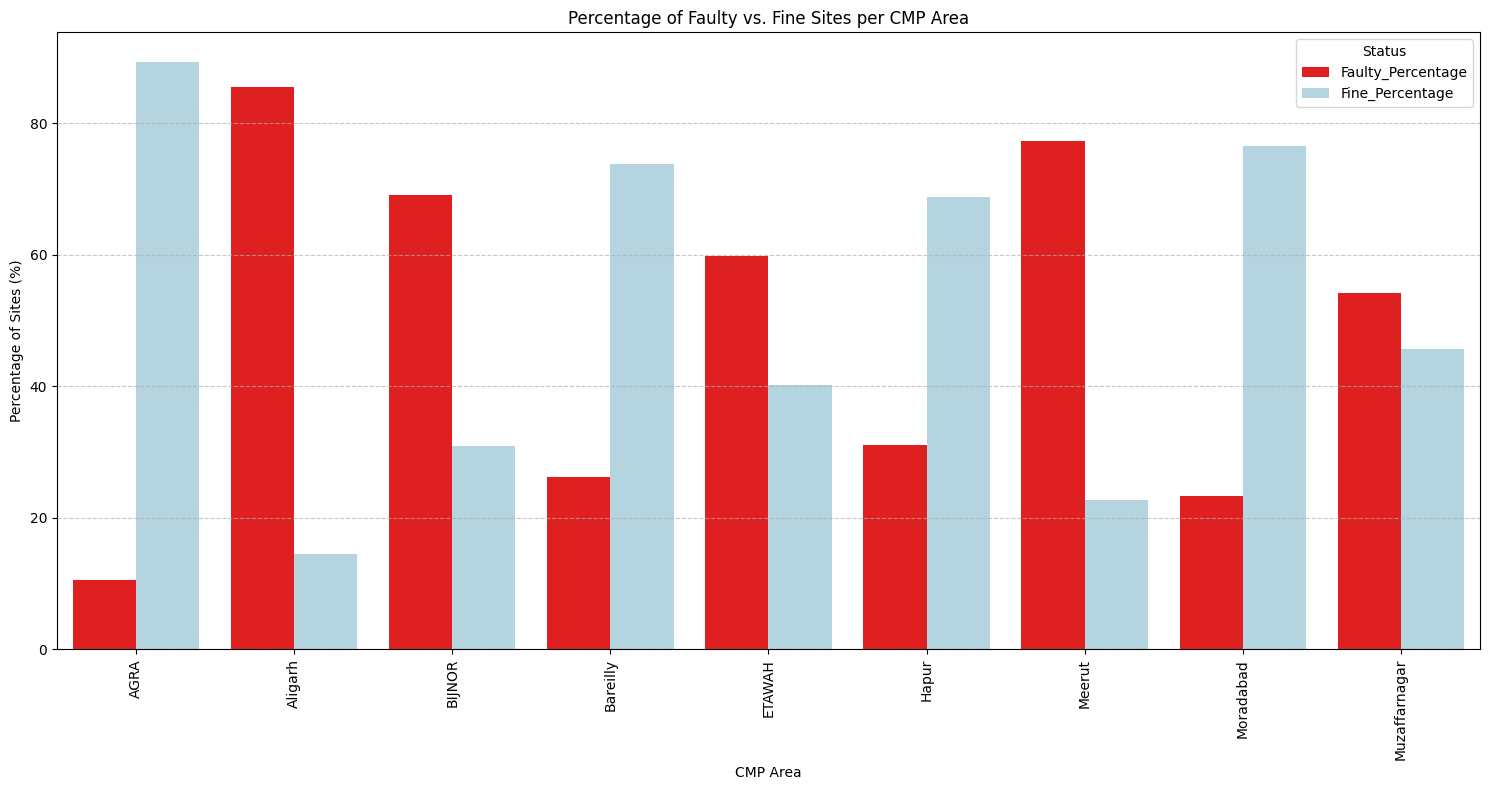

In [168]:
cmp_action_summary_melted = cmp_action_summary.melt(
    id_vars=['CMP'],
    value_vars=['Faulty_Percentage', 'Fine_Percentage'],
    var_name='Site_Status',
    value_name='Percentage'
)

plt.figure(figsize=(15, 8))
sns.barplot(x='CMP', y='Percentage', hue='Site_Status', data=cmp_action_summary_melted, palette={'Faulty_Percentage': 'red', 'Fine_Percentage': 'lightblue'})
plt.title('Percentage of Faulty vs. Fine Sites per CMP Area')
plt.xlabel('CMP Area')
plt.ylabel('Percentage of Sites (%)')
plt.xticks(rotation=90)
plt.legend(title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This stacked bar chart clearly visualizes the proportion of faulty versus fine sites within each CMP area. You can see at a glance which areas have a higher percentage of sites needing action (red bars) and which have a higher percentage of fine sites (green bars). This helps in prioritizing interventions and resource allocation across different CMPs.

In [169]:
problem_columns = [
    'Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG',
    'Replacement of Under Rated/Faulty 4Core power cable in Meter Box',
    'Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ',
    'Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)',
    'Removal of Faulty battery from Battery Management Power System & return to WH for RSNR',
    'Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands',
    'Installation of Rectifier Module on Sites with <2 RM',
    'Correction of Bypass of Rectifier Module ',
    'Replacement of Faulty Class-C and Class-B SPD ',
    'Identification and replacement of Under Rated/damage GBM Power Cable ',
    'Shifting of BM and SMPS from GBM to ODC on feasible sites',
    'Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch',
    'Installation of Bird Mesh at GBM top Canopy',
    'GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'
]

# Group by CMP and sum the problem columns (where 1 indicates a problem)
problem_summary_cmp = df.groupby('CMP')[problem_columns].sum()

# Shorter names for problem columns for better visualization
short_problem_names = {
    'Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG': 'MCB Replacement',
    'Replacement of Under Rated/Faulty 4Core power cable in Meter Box': '4Core Cable Replacement',
    'Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) ': 'Electrical Hygiene',
    'Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)': 'Illegal Power Tapping',
    'Removal of Faulty battery from Battery Management Power System & return to WH for RSNR': 'Battery Removal',
    'Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands': 'Roxtec/Exit Points Sealing',
    'Installation of Rectifier Module on Sites with <2 RM': 'Rectifier Module Install',
    'Correction of Bypass of Rectifier Module ': 'Bypass Correction',
    'Replacement of Faulty Class-C and Class-B SPD ': 'SPD Replacement',
    'Identification and replacement of Under Rated/damage GBM Power Cable ': 'GBM Power Cable Replace',
    'Shifting of BM and SMPS from GBM to ODC on feasible sites': 'Shifting BM/SMPS',
    'Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch': 'Deep Cleaning GBM',
    'Installation of Bird Mesh at GBM top Canopy': 'Bird Mesh Install',
    'GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges': 'GBM Protection Ring'
}

problem_summary_cmp_renamed = problem_summary_cmp.rename(columns=short_problem_names)

display(problem_summary_cmp_renamed.head())

,MCB Replacement,4Core Cable Replacement,Electrical Hygiene,Illegal Power Tapping,Battery Removal,Roxtec/Exit Points Sealing,Rectifier Module Install,Bypass Correction,SPD Replacement,GBM Power Cable Replace,Shifting BM/SMPS,Deep Cleaning GBM,Bird Mesh Install,GBM Protection Ring
CMP,,,,,,,,,,,,,,
AGRA,48.0,37.0,34.0,39.0,36.0,32.0,35.0,35.0,44.0,32,32,33,32,32
Aligarh,152.0,13.0,5.0,8.0,12.0,0.0,141.0,33.0,127.0,0,29,20,11,0
BIJNOR,282.0,96.0,2.0,18.0,38.0,18.0,98.0,45.0,359.0,3,27,18,18,17
Bareilly,52.0,0.0,15.0,11.0,148.0,0.0,61.0,41.0,28.0,0,0,1,19,19
ETAWAH,601.0,410.0,310.0,346.0,16.0,286.0,359.0,19.0,635.0,0,0,1,1,0


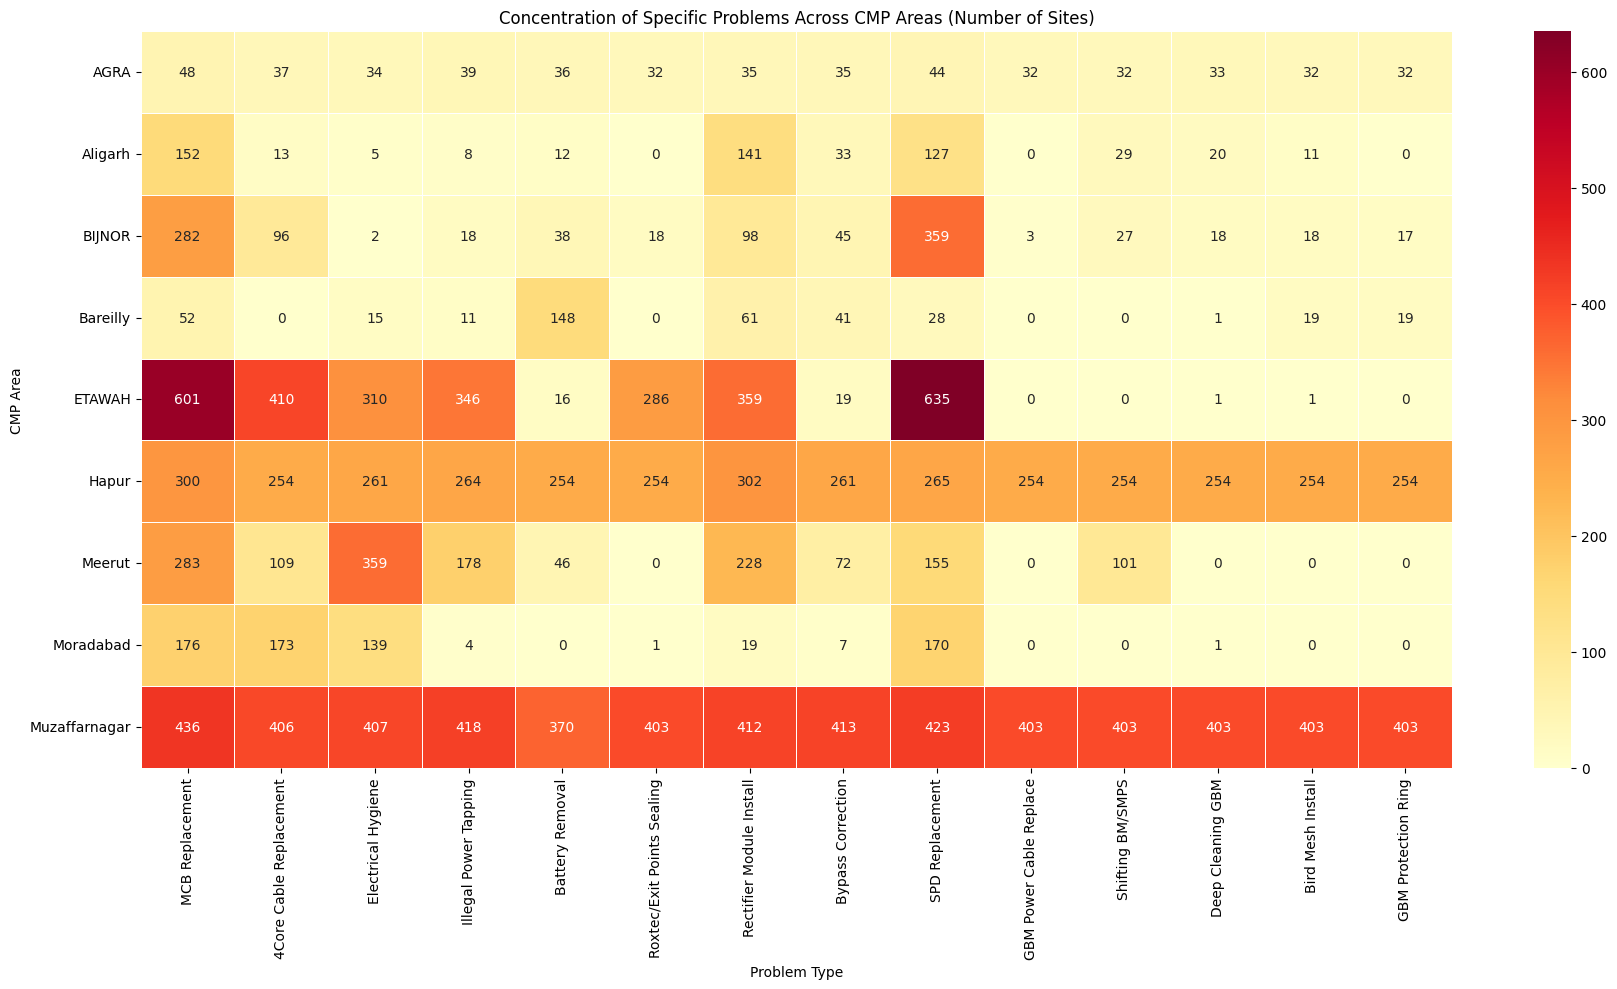

In [170]:
plt.figure(figsize=(18, 10))
sns.heatmap(problem_summary_cmp_renamed, annot=True, fmt='g', cmap='YlOrRd', linewidths=.5)
plt.title('Concentration of Specific Problems Across CMP Areas (Number of Sites)')
plt.xlabel('Problem Type')
plt.ylabel('CMP Area')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [171]:
# Identify top problems for each CMP and generate a textual summary
summary_text = []
for cmp_area in problem_summary_cmp_renamed.index:
    # Filter out problems with 0 occurrences to only list actual issues
    relevant_problems = problem_summary_cmp_renamed.loc[cmp_area][problem_summary_cmp_renamed.loc[cmp_area] > 0]
    if not relevant_problems.empty:
        top_problems = relevant_problems.nlargest(3) # Get top 3 problems
        summary_text.append(f"- **{cmp_area}**: {', '.join([f'{problem} ({int(count)})' for problem, count in top_problems.items()])}")
    else:
        summary_text.append(f"- **{cmp_area}**: No specific problems reported (all are fine or 'OK').")

for item in summary_text:
    print(item)

- **AGRA**: MCB Replacement (48), SPD Replacement (44), Illegal Power Tapping (39)
- **Aligarh**: MCB Replacement (152), Rectifier Module Install (141), SPD Replacement (127)
- **BIJNOR**: SPD Replacement (359), MCB Replacement (282), Rectifier Module Install (98)
- **Bareilly**: Battery Removal (148), Rectifier Module Install (61), MCB Replacement (52)
- **ETAWAH**: SPD Replacement (635), MCB Replacement (601), 4Core Cable Replacement (410)
- **Hapur**: Rectifier Module Install (302), MCB Replacement (300), SPD Replacement (265)
- **Meerut**: Electrical Hygiene (359), MCB Replacement (283), Rectifier Module Install (228)
- **Moradabad**: MCB Replacement (176), 4Core Cable Replacement (173), SPD Replacement (170)
- **Muzaffarnagar**: MCB Replacement (436), SPD Replacement (423), Illegal Power Tapping (418)


### Detailed Breakdown of Specific Problems by CMP Area

### Visualizing Each Specific Problem by CMP Area

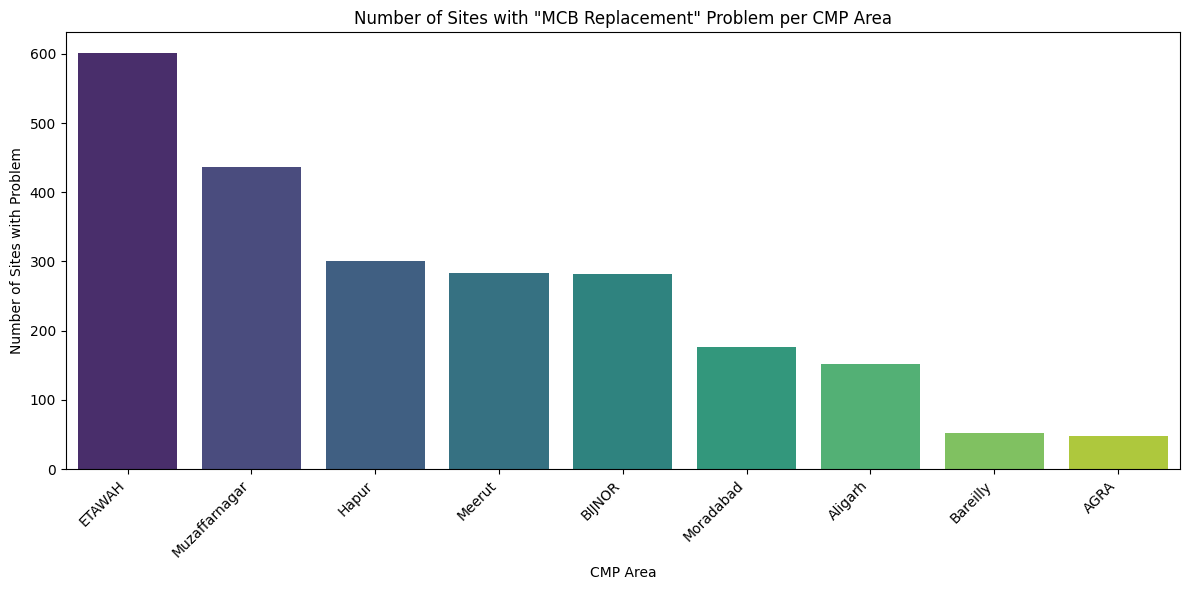

In [172]:
# MCB Replacement
problem_col = 'Replacement of Under Rated/Faulty 4-Pole MCB in Meter Box, ODC  & DG'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

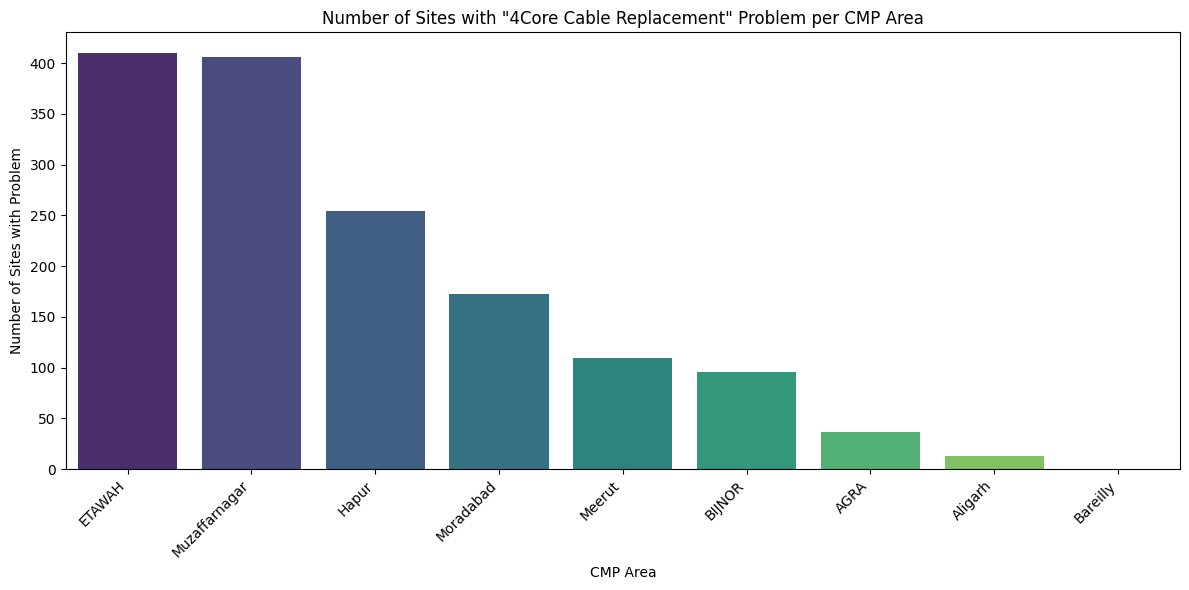

In [173]:
# 4Core Cable Replacement
problem_col = 'Replacement of Under Rated/Faulty 4Core power cable in Meter Box'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

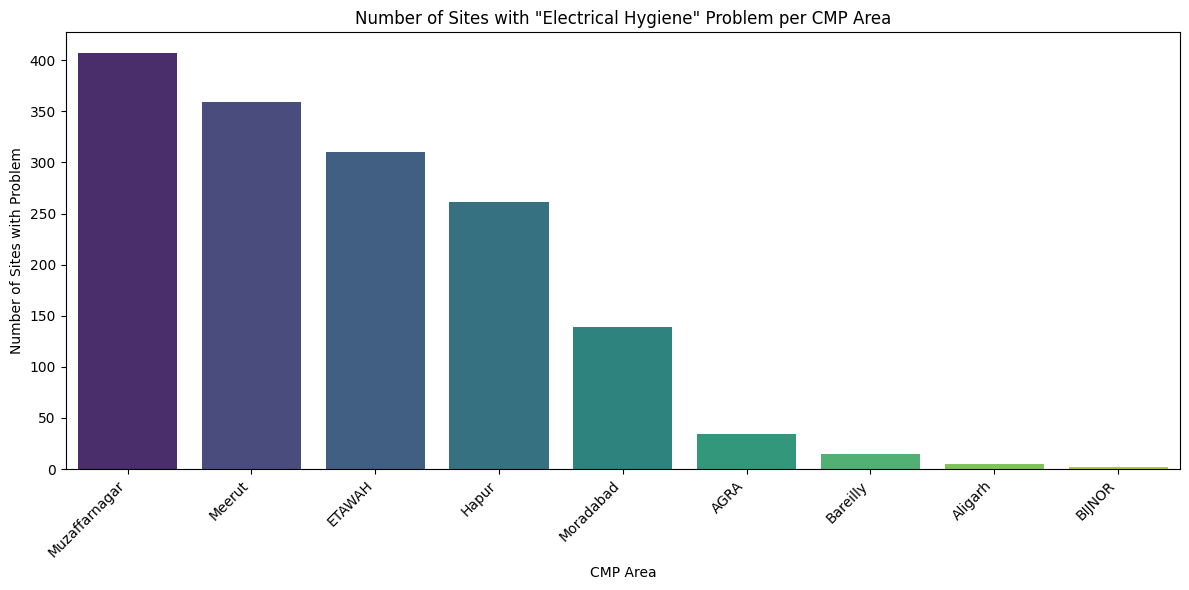

In [174]:
# Electrical Hygiene
problem_col = 'Electrical Hygiene Correction ( Damage Insulation,  Loose connection,  Improper Termination of all Power Cables in AMF, SMPS, Battery, ISP Equipment  w/o using LUGS) '
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

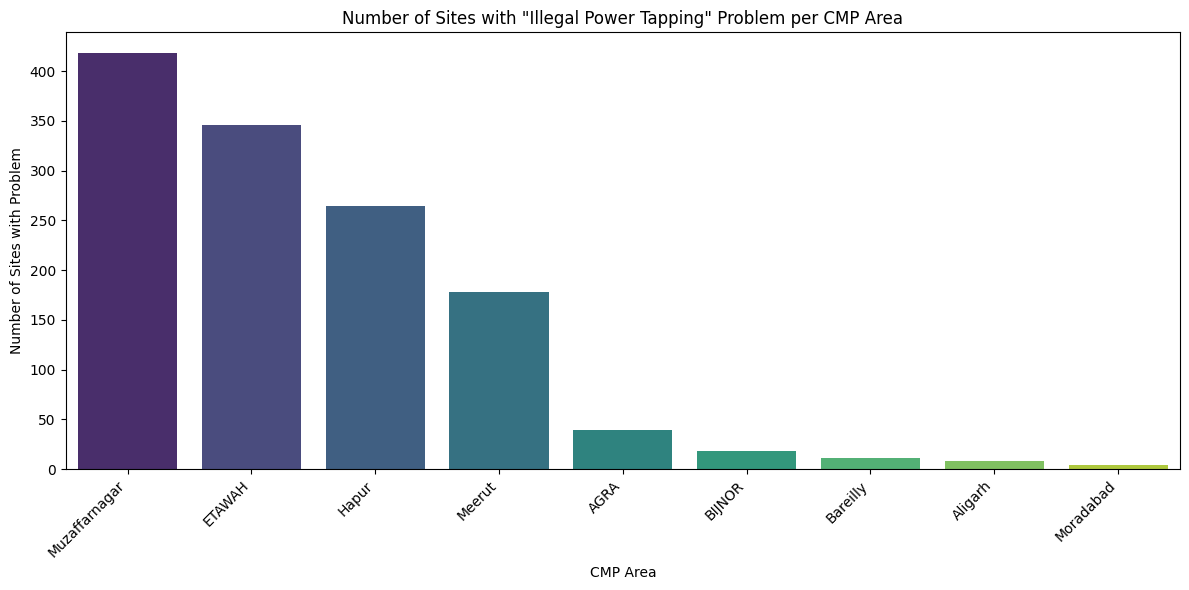

In [175]:
# Illegal Power Tapping
problem_col = 'Illegal power tapping correction (DG AMF Panel/Mains EB meter Box)'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

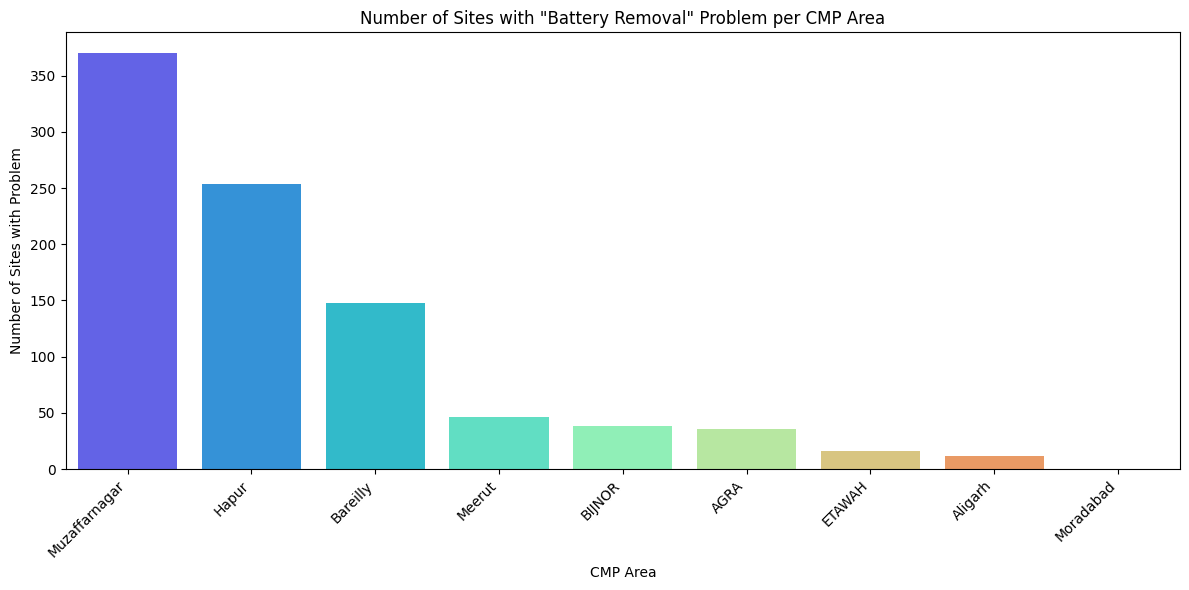

In [176]:
# Battery Removal
problem_col = 'Removal of Faulty battery from Battery Management Power System & return to WH for RSNR'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

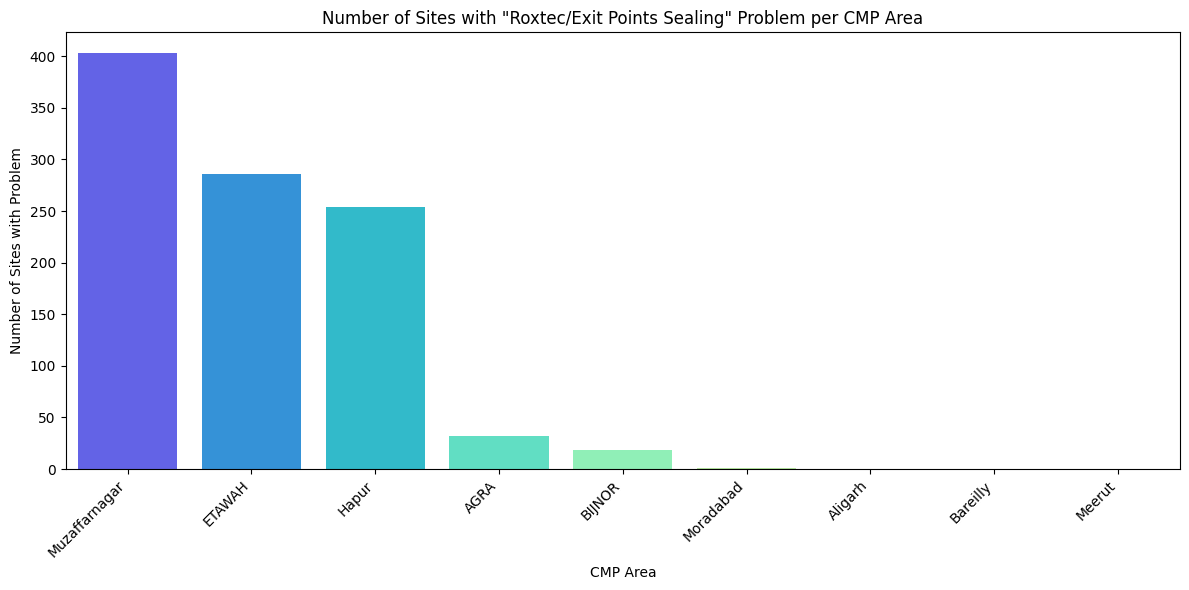

In [177]:
# Roxtec/Exit Points Sealing
problem_col = 'Sealing of Roxtec/Exit Points & Entering of Power & ISP cables  in ODC/GBM/DG in "U" Shape using Glands'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

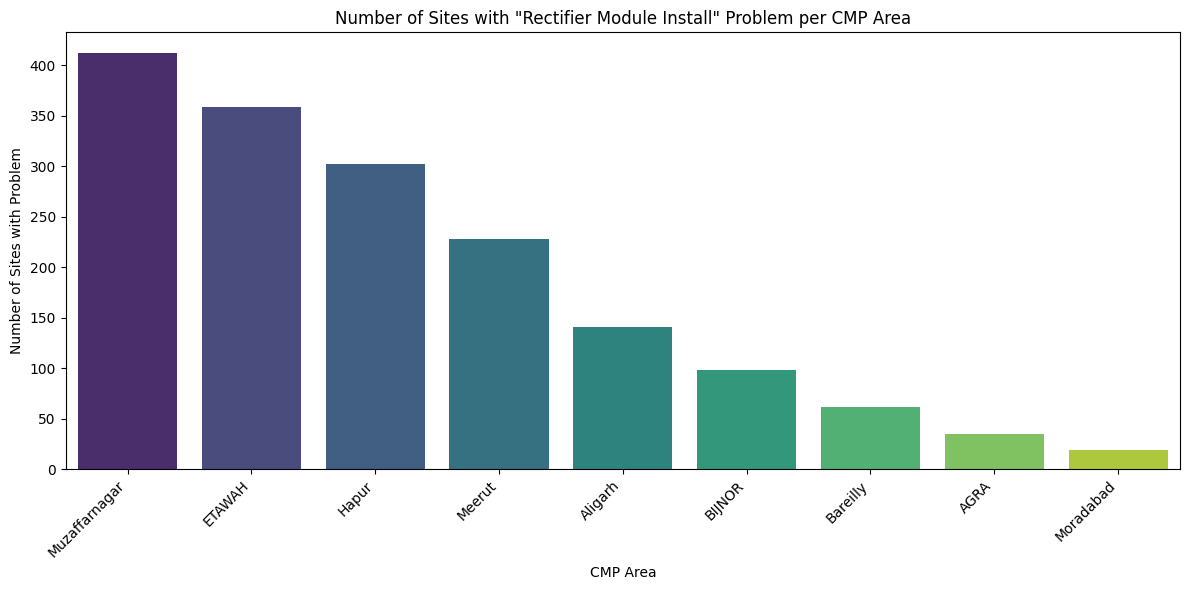

In [178]:
# Rectifier Module Install
problem_col = 'Installation of Rectifier Module on Sites with <2 RM'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

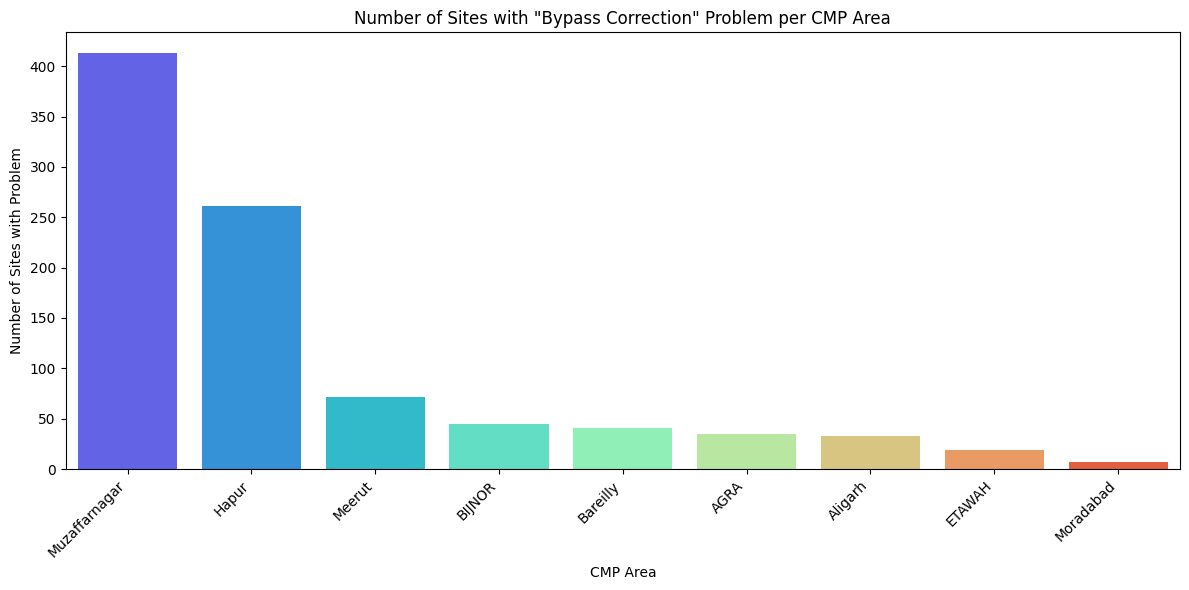

In [179]:
# Bypass Correction
problem_col = 'Correction of Bypass of Rectifier Module '
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

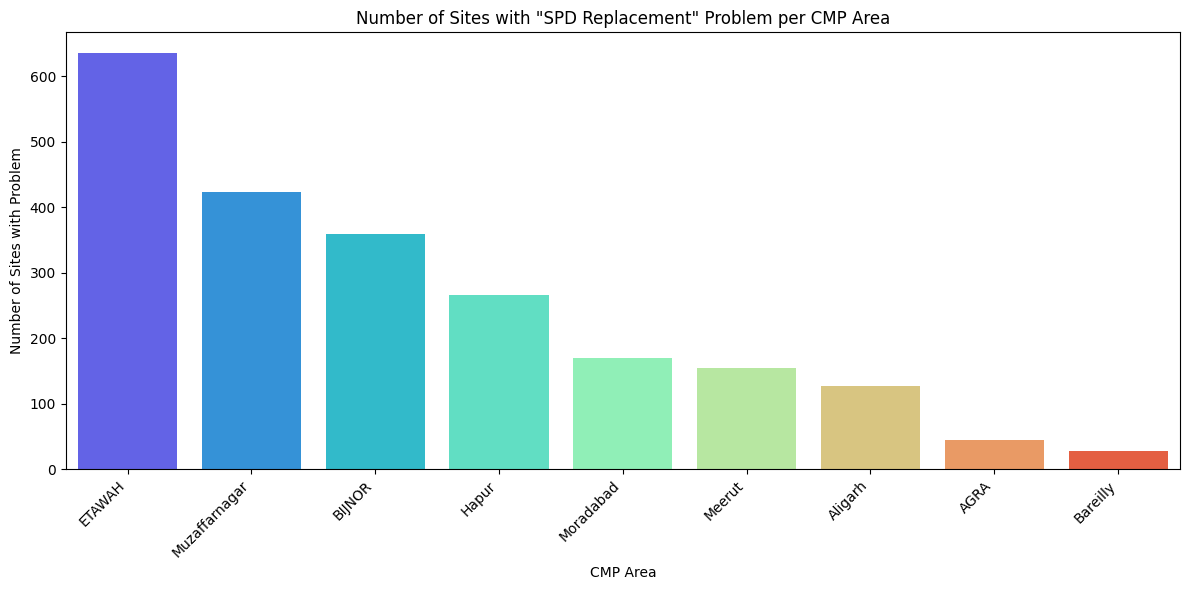

In [180]:
# SPD Replacement
problem_col = 'Replacement of Faulty Class-C and Class-B SPD '
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

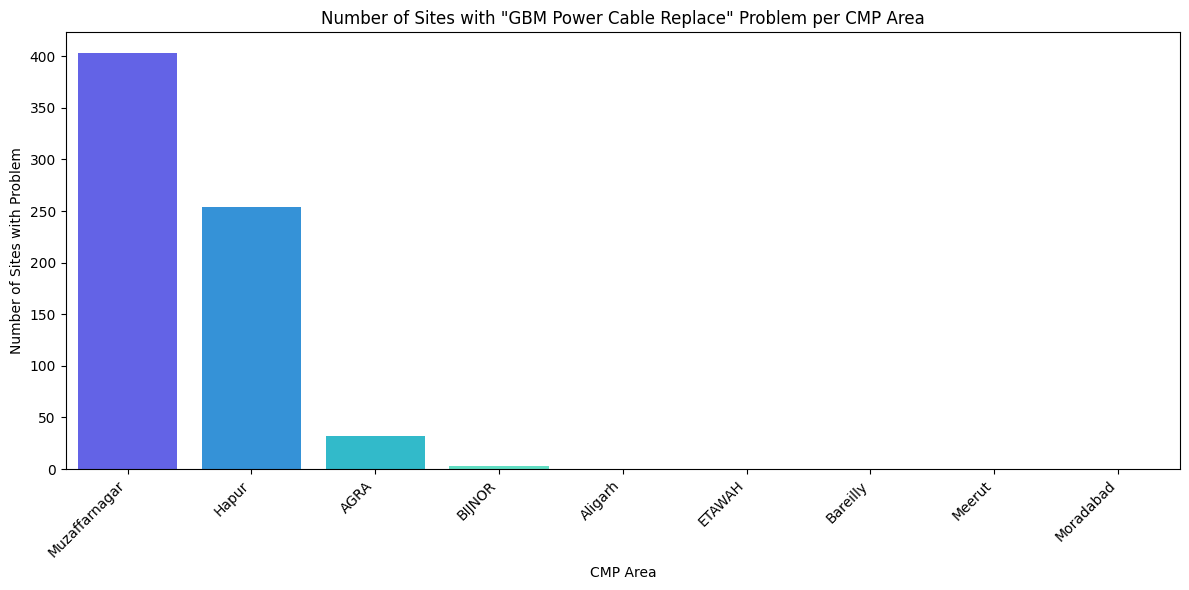

In [181]:
# GBM Power Cable Replace
problem_col = 'Identification and replacement of Under Rated/damage GBM Power Cable '
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

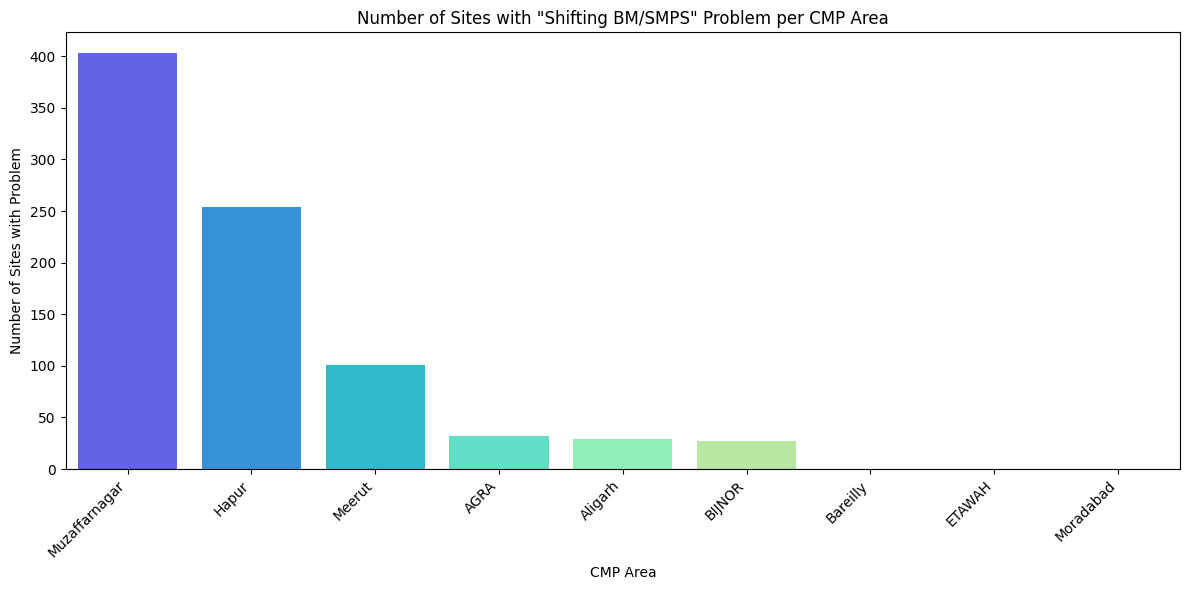

In [182]:
# Shifting BM/SMPS
problem_col = 'Shifting of BM and SMPS from GBM to ODC on feasible sites'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

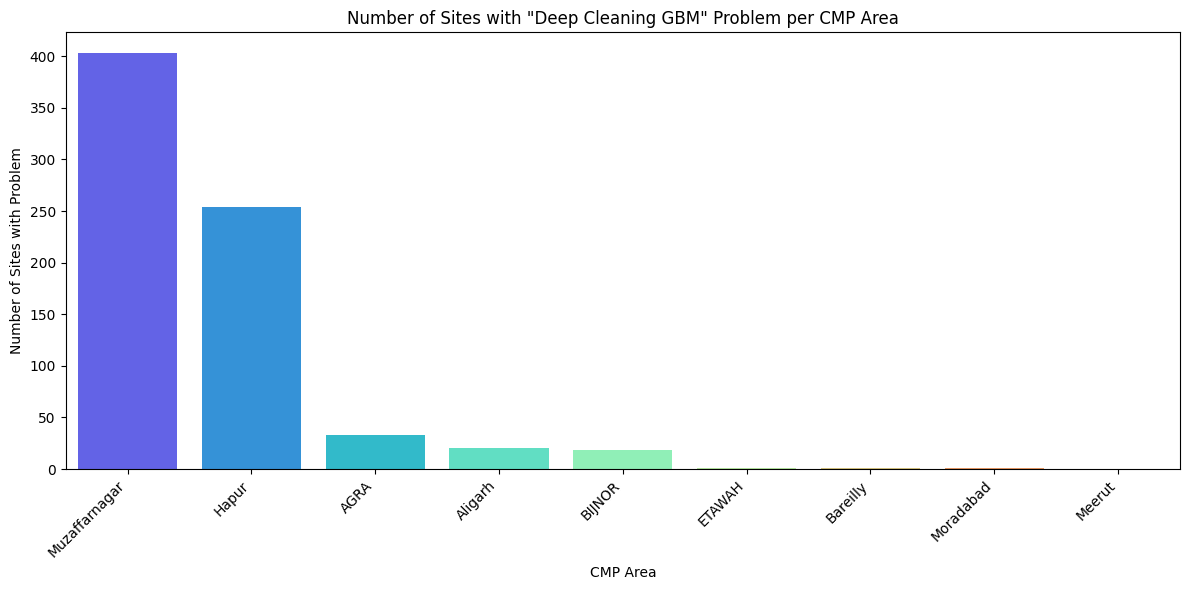

In [183]:
# Deep Cleaning GBM
problem_col = 'Deep Cleaning of Complete GBM Enclosure & removal of Dry Vegetation. Removal of  unwanted Cable Bunch'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='rainbow', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

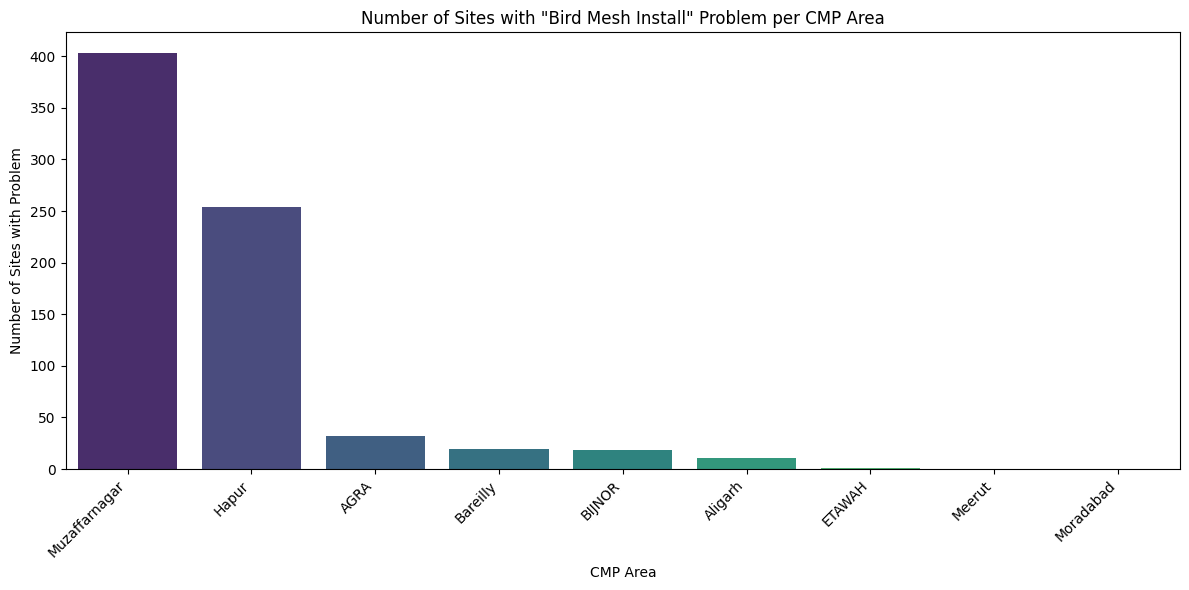

In [184]:
# Bird Mesh Install
problem_col = 'Installation of Bird Mesh at GBM top Canopy'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

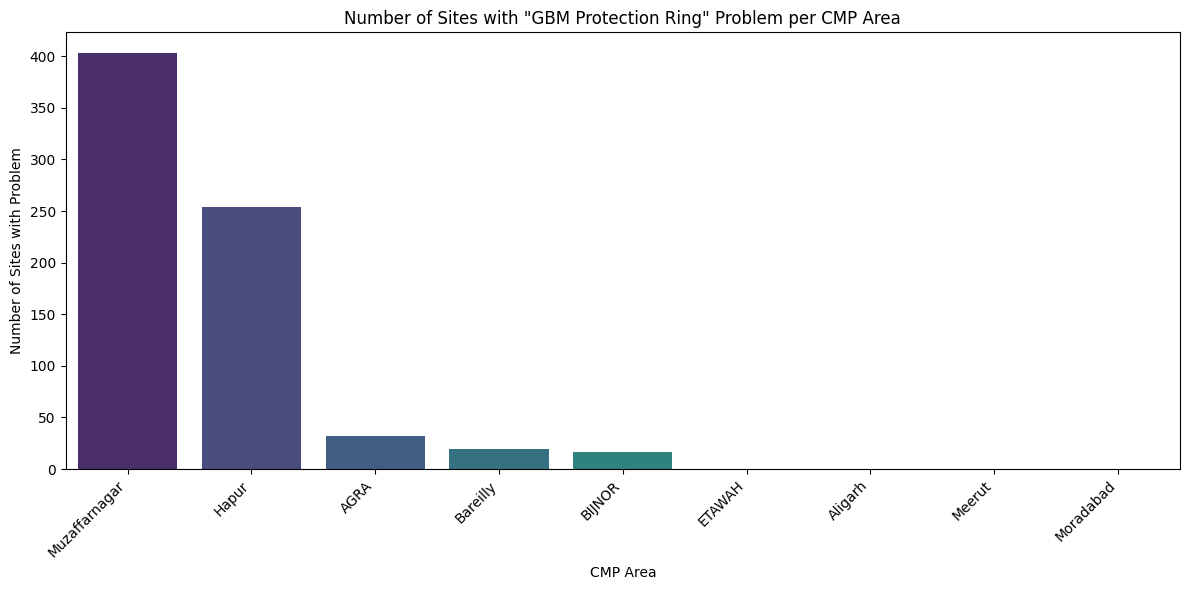

In [185]:
# GBM Protection Ring
problem_col = 'GBM Protection Ring installation at old GBM sites to avoid damages from Sharp Edges'
short_name = short_problem_names[problem_col]
problem_counts = df.groupby('CMP')[problem_col].sum().sort_values(ascending=False)

if not problem_counts.empty and problem_counts.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=problem_counts.index, y=problem_counts.values, hue=problem_counts.index, palette='viridis', legend=False)
    plt.title(f'Number of Sites with "{short_name}" Problem per CMP Area')
    plt.xlabel('CMP Area')
    plt.ylabel('Number of Sites with Problem')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"No '{short_name}' problems reported across all CMP areas.")

<a id='key-insights-from-fire-prevention-data-analysis'></a>
# **Key Insights from Fire Prevention Data Analysis**

Our comprehensive analysis of the fire prevention data has unveiled critical insights into the state of infrastructure across various CMP areas. These findings are crucial for informed decision-making and targeted intervention strategies.

## **1. The Scope of the Challenge: Significant Fault Rate**

*   **Nearly half of all sites (46.38%) require immediate action due to reported faults.** This high percentage underscores the widespread nature of issues and the urgent need for a robust prevention and maintenance program.

## **2. Regional Disparities: Where to Focus Efforts**

Our CMP-wise analysis revealed significant variations in site health:

*   **High-Priority Areas**: Regions like **Aligarh (85.53% faulty sites)** and **Meerut (77.34% faulty sites)** exhibit alarmingly high percentages of problematic sites. These areas should be prioritized for immediate and intensive intervention.
*   **Areas for Sustained Monitoring**: Other CMPs like **ETAWAH (59.84%)** and **Bijnor (71.03%)** also show a substantial proportion of faulty sites, demanding continuous attention.
*   **Relatively Healthier Areas**: **AGRA (10.61% faulty sites)** stands out with a significantly lower fault rate, suggesting that its prevention and maintenance protocols might serve as a benchmark for other regions.

## **3. Pinpointing the Problems: What Needs Fixing**

Our detailed breakdown of specific problem types across CMPs highlights recurring and localized issues:

*   **Common Widespread Issues**:
    *   **MCB Replacement**, **SPD Replacement**, and **Illegal Power Tapping** are frequently identified as top problems across multiple CMP areas. These are foundational electrical safety concerns that need systematic resolution.
    *   For instance, **Muzaffarnagar** shows high numbers for 'MCB Replacement (436)', 'SPD Replacement (423)', and 'Illegal Power Tapping (418)', indicating a need for broad electrical infrastructure overhaul.

*   **Localized Critical Concerns**:
    *   **Battery Removal** is a dominant issue in **Bareilly (148 sites)**, suggesting potential problems with battery management systems or theft.
    *   **Electrical Hygiene** is a significant concern in **Meerut (359 sites)**, pointing towards poor maintenance practices that could lead to fire hazards.
    *   **Rectifier Module Installation** is a key problem in **Hapur (302 sites)** and **Aligarh (141 sites)**, suggesting issues with power conversion and supply stability.


## **Actionable Recommendations:**

Based on these insights, the following actions are recommended:

1.  **Prioritize Interventions**: Focus resources and personnel on high-fault areas like Aligarh and Meerut first.
2.  **Systematic Electrical Audits**: Implement regular, thorough audits for MCB, SPD, and power tapping issues across all CMPs.
3.  **Targeted Training and Maintenance**: Develop specialized programs for battery management in Bareilly and electrical hygiene in Meerut.
4.  **Best Practice Sharing**: Investigate practices in lower-fault areas like AGRA to identify and replicate successful strategies.

This analytical framework allows for a data-driven approach to fire prevention, ensuring that efforts are directed efficiently to mitigate risks and enhance safety across all sites.